# nb02_SM8 — Spectral dimension on tiled 600‑cell graphs

Research‑grade notebook for estimating the spectral dimension from random walks on graphs derived from the 600‑cell.

This version assumes:

- Edge list is stored in a text file (two integers per line)
- Filenames are prefixed with `nb02_SM8_`
- GPU backend: **PyTorch CUDA** (`device = torch.device("cuda")`)

We will:

1. Load an edge list (e.g. `nb02_SM8_tiny1ring_edgelist.txt`)
2. Compute basic graph diagnostics (size, degree stats, connectivity)
3. Build a CSR‑style neighbor structure
4. Run GPU random walks
5. Estimate return probability $P(t)$
6. Fit $\log P(t)$ vs $\log t$ to extract an effective spectral dimension
7. Plot diagnostics (degree histogram, return probability, residuals)


In [1]:
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True

# Use CUDA GPU
device = torch.device("cuda")
print("Using device:", device)


Using device: cuda


## 1. Load edge list

Set `EDGE_LIST_PATH` to the graph you want to analyze.

- For the tiny 1‑ring surrogate: `nb02_SM8_tiny1ring_edgelist.txt`
- For the chain: `nb02_SM8_600cell_chain_edgelist.txt`
- Later: `nb02_SM8_tiled600_edgelist.txt` (true H₄ tiling)


In [2]:
# Choose which graph to analyze
# For now, use the tiny 1-ring surrogate

EDGE_LIST_PATH = Path("nb02_SM8_tiny1ring_edgelist.txt")
print("Loading edge list from:", EDGE_LIST_PATH)

edges = np.loadtxt(EDGE_LIST_PATH, dtype=int)
if edges.ndim == 1:
    edges = edges.reshape(1, 2)

print("Loaded edges shape:", edges.shape)

# Ensure edges are undirected (add reversed if not already)
u = edges[:, 0]
v = edges[:, 1]
num_vertices = int(max(u.max(), v.max()) + 1)
print("Number of vertices:", num_vertices)

# Build undirected edge list (both directions)
edges_undirected = np.vstack([edges, np.column_stack([v, u])])
print("Undirected edges count:", edges_undirected.shape[0])


Loading edge list from: nb02_SM8_tiny1ring_edgelist.txt
Loaded edges shape: (5760, 2)
Number of vertices: 840
Undirected edges count: 11520


## 2. Basic graph diagnostics

We compute:

- Degree of each vertex
- Degree statistics
- Degree histogram
- A simple connectivity check via BFS


Degree stats:
  min: 13
  max: 18
  mean: 13.714285714285714
Unique degrees and counts:
  degree 13: 720 vertices
  degree 18: 120 vertices


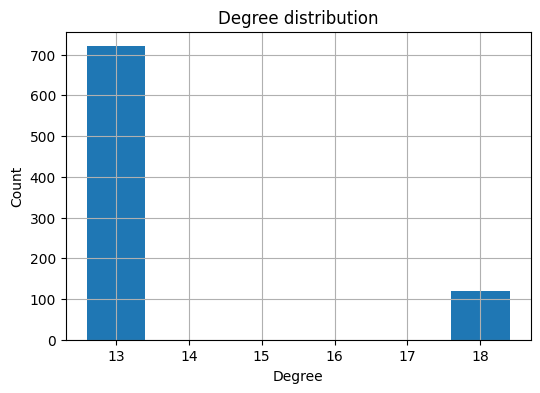

In [3]:
# Degree computation
deg = np.zeros(num_vertices, dtype=int)
for a, b in edges_undirected:
    deg[a] += 1

print("Degree stats:")
print("  min:", deg.min())
print("  max:", deg.max())
print("  mean:", deg.mean())

# Degree histogram
unique_deg, counts_deg = np.unique(deg, axis=0, return_counts=True)
print("Unique degrees and counts:")
for d, c in zip(unique_deg, counts_deg):
    print(f"  degree {d}: {c} vertices")

plt.figure()
plt.bar(unique_deg, counts_deg, width=0.8)
plt.xlabel("Degree")
plt.ylabel("Count")
plt.title("Degree distribution")
plt.show()


### Connectivity check (BFS)

We perform a simple BFS from vertex 0 and verify that all vertices are reachable.
This is a sanity check that the graph is a single connected component.


In [4]:
from collections import deque

# Build adjacency list for BFS
adj_list = [[] for _ in range(num_vertices)]
for a, b in edges_undirected:
    adj_list[a].append(b)

visited = np.zeros(num_vertices, dtype=bool)
q = deque([0])
visited[0] = True

while q:
    x = q.popleft()
    for y in adj_list[x]:
        if not visited[y]:
            visited[y] = True
            q.append(y)

num_visited = visited.sum()
print(f"BFS visited {num_visited} / {num_vertices} vertices")
if num_visited == num_vertices:
    print("Graph is connected.")
else:
    print("Graph is NOT fully connected.")


BFS visited 840 / 840 vertices
Graph is connected.


## 3. Build CSR‑style neighbor structure

We construct a compressed sparse row (CSR) representation:

- `neighbors_flat`: concatenation of all neighbor lists
- `offsets[i]`: start index of neighbors of vertex `i` in `neighbors_flat`

This structure is convenient for GPU random walks: for a vertex `i`, neighbors are
`neighbors_flat[offsets[i]:offsets[i+1]]`.


In [5]:
# Build CSR-like neighbor structure
neighbors_flat_list = []
offsets = np.zeros(num_vertices + 1, dtype=np.int64)

cursor = 0
for i in range(num_vertices):
    nbrs = adj_list[i]
    offsets[i] = cursor
    neighbors_flat_list.extend(nbrs)
    cursor += len(nbrs)
offsets[num_vertices] = cursor

neighbors_flat = np.array(neighbors_flat_list, dtype=np.int64)

print("neighbors_flat length:", len(neighbors_flat))
print("offsets shape:", offsets.shape)

# Quick consistency check
deg_from_offsets = offsets[1:] - offsets[:-1]
print("Max |deg - deg_from_offsets|:", np.max(np.abs(deg - deg_from_offsets)))


neighbors_flat length: 11520
offsets shape: (841,)
Max |deg - deg_from_offsets|: 0


## 4. Move neighbor structure to GPU

We move `neighbors_flat` and `offsets` to CUDA tensors.
Random walks will be performed entirely on the GPU.


In [6]:
neighbors_flat_t = torch.from_numpy(neighbors_flat).to(device)
offsets_t = torch.from_numpy(offsets).to(device)

num_vertices_t = torch.tensor(num_vertices, device=device, dtype=torch.long)

print("neighbors_flat_t:", neighbors_flat_t.shape, neighbors_flat_t.dtype)
print("offsets_t:", offsets_t.shape, offsets_t.dtype)


neighbors_flat_t: torch.Size([11520]) torch.int64
offsets_t: torch.Size([841]) torch.int64


## 5. GPU random walk kernel

We simulate many independent random walkers.

- Each walker starts at a random vertex (or we could fix an origin)
- At each time step, a walker at vertex `i` chooses a neighbor uniformly at random
- We track the fraction of walkers that are at their starting vertex at each time `t`

This gives an estimate of the return probability $P(t)$.


In [7]:
def random_walk_return_prob(neighbors_flat_t, offsets_t, num_vertices,
                            num_walkers=200000, T_max=200, seed=12345):
    """Run random walks on GPU and estimate return probability P(t).

    neighbors_flat_t: 1D tensor of neighbors (int64, on device)
    offsets_t: 1D tensor of length num_vertices+1 (int64, on device)
    num_vertices: int
    num_walkers: number of walkers
    T_max: maximum time
    """
    torch.manual_seed(seed)

    num_vertices_t = torch.tensor(num_vertices, device=device, dtype=torch.long)

    # Initial positions: random vertices
    start_pos = torch.randint(low=0, high=num_vertices, size=(num_walkers,), device=device)
    current_pos = start_pos.clone()

    P_t = []

    for t in range(T_max + 1):
        # Estimate return probability at time t
        returns = (current_pos == start_pos).float().mean().item()
        P_t.append(returns)

        if t == T_max:
            break

        # One random-walk step
        # For each walker at vertex i, neighbors are neighbors_flat[offsets[i]:offsets[i+1]]
        offs = offsets_t[current_pos]
        offs_next = offsets_t[current_pos + 1]
        degs = offs_next - offs

        # Sample a neighbor index for each walker
        # k in [0, degs)
        r = torch.rand_like(degs, dtype=torch.float)
        k = (r * degs.to(torch.float)).to(torch.long)
        idx = offs + k
        current_pos = neighbors_flat_t[idx]

    return np.array(P_t)

T_MAX = 200
NUM_WALKERS = 200000

print("Running random walks...")
P_t = random_walk_return_prob(neighbors_flat_t, offsets_t, num_vertices,
                              num_walkers=NUM_WALKERS, T_max=T_MAX, seed=12345)
print("Done. P_t shape:", P_t.shape)


Running random walks...
Done. P_t shape: (201,)


## 6. Plot return probability (log–log)

We plot $P(t)$ vs $t$ on log–log axes.
Later we will fit a line in a chosen time window to estimate the spectral dimension.


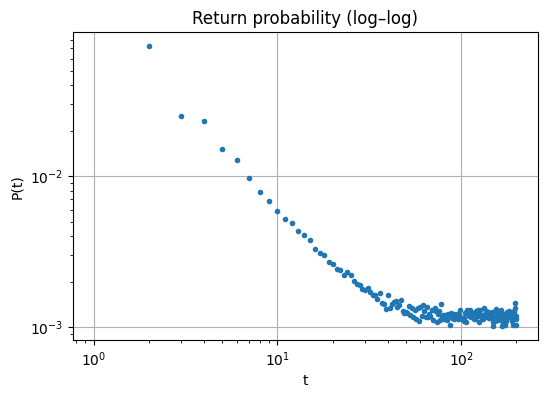

In [8]:
t_vals = np.arange(len(P_t))

plt.figure()
plt.loglog(t_vals[1:], P_t[1:], marker="o", linestyle="none", markersize=3)
plt.xlabel("t")
plt.ylabel("P(t)")
plt.title("Return probability (log–log)")
plt.show()


## 7. Fit log–log slope and estimate spectral dimension

For a diffusion process on a space with spectral dimension $d_s$, we expect:

$$ P(t) \sim t^{-d_s/2} $$

So on a log–log plot:

$$ \log P(t) \approx -\frac{d_s}{2} \log t + \text{const} $$

We choose a fitting window `[t_min_fit, t_max_fit]` where the curve looks approximately linear.
For now, we use a simple heuristic:

- `t_min_fit = 5`
- `t_max_fit = T_MAX // 2`

You can adjust these based on the plot.


Fit results (log P = a log t + b):
  a = -0.7375150040072216
  b = -3.607984654337248
Estimated spectral dimension d_s ≈ 1.4750300080144432


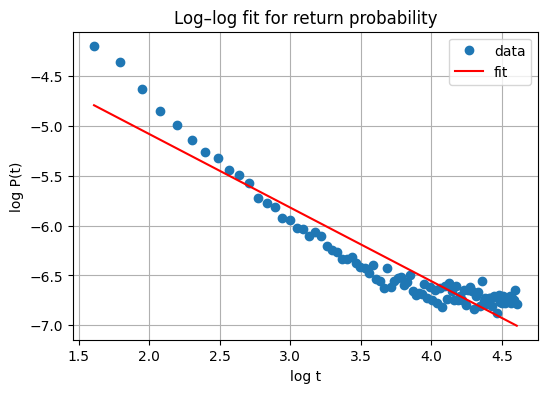

In [9]:
t_min_fit = 5
t_max_fit = T_MAX // 2

mask = (t_vals >= t_min_fit) & (t_vals <= t_max_fit)
t_fit = t_vals[mask]
P_fit = P_t[mask]

log_t = np.log(t_fit)
log_P = np.log(P_fit)

# Linear fit: log P = a * log t + b
A = np.vstack([log_t, np.ones_like(log_t)]).T
a, b = np.linalg.lstsq(A, log_P, rcond=None)[0]

ds_est = -2.0 * a

print("Fit results (log P = a log t + b):")
print("  a =", a)
print("  b =", b)
print("Estimated spectral dimension d_s ≈", ds_est)

# Plot fit overlay
log_P_fit_line = a * log_t + b

plt.figure()
plt.plot(log_t, log_P, "o", label="data")
plt.plot(log_t, log_P_fit_line, "r-", label="fit")
plt.xlabel("log t")
plt.ylabel("log P(t)")
plt.title("Log–log fit for return probability")
plt.legend()
plt.show()


## 8. Residual diagnostics

We plot residuals:

$$ r(t) = \log P(t) - (a \log t + b) $$

to see how well the power‑law model fits in the chosen window.


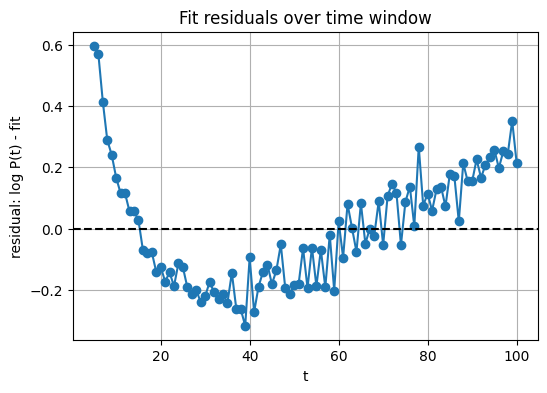

Residual stats:
  mean: 6.5133084111342514e-15
  std: 0.18921512767395957
  max |residual|: 0.5965966179464699


In [10]:
residuals = log_P - log_P_fit_line

plt.figure()
plt.plot(t_fit, residuals, "o-")
plt.axhline(0.0, color="k", linestyle="--")
plt.xlabel("t")
plt.ylabel("residual: log P(t) - fit")
plt.title("Fit residuals over time window")
plt.show()

print("Residual stats:")
print("  mean:", residuals.mean())
print("  std:", residuals.std())
print("  max |residual|:", np.max(np.abs(residuals)))


## 9. Optional: export P(t) data

You can export the return probability data for archival or external analysis.


In [11]:
EXPORT_PATH = Path("nb02_SM8_return_prob_data_tiny1ring.csv")

data = np.column_stack([t_vals, P_t])
np.savetxt(EXPORT_PATH, data, delimiter=",", header="t,P(t)", comments="")
print("Exported P(t) data to:", EXPORT_PATH)


Exported P(t) data to: nb02_SM8_return_prob_data_tiny1ring.csv
